# DP-VAE on Pre-trained Embeddings (CIFAR-10)

Instead of training a VAE on raw pixels, we use a **public pre-trained encoder** (ResNet-18
trained on ImageNet) to extract dense latent embeddings from CIFAR-10. A lightweight MLP-based
VAE is then trained on those embeddings using **Opacus** for differential privacy.

**Pipeline:**
1. **Public Encoder** — frozen ResNet-18 → 512-dim embeddings
2. **DP-VAE** — small MLP VAE trained on embeddings with per-sample DP-SGD
3. **Embedding Decoder** — lightweight ConvTranspose network mapping embeddings → images (trained once, non-DP)
4. **Generator** — sample z → DP-VAE decoder → synthetic embedding → image decoder → synthetic image

**Downstream evaluation:** train CIFAR-10 classifier on *synthetic data only*, test on real test set.

**Privacy budgets compared:** no-DP, ε=8, ε=1

## 1. Setup

In [1]:
from pathlib import Path
import sys
import gc
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms, models
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
from opacus import PrivacyEngine
from opacus.accountants.utils import get_noise_multiplier
from opacus.utils.batch_memory_manager import BatchMemoryManager

cwd = Path.cwd().resolve()
if (cwd / 'strategy').exists():
    REPO_ROOT = cwd
else:
    REPO_ROOT = cwd.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from models.cifar.cifar_cnn import CIFAR_CNN


def get_best_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


DEVICE = get_best_device()
print('Repo root:', REPO_ROOT)
print('Torch:', torch.__version__)
print('Device:', DEVICE)

Repo root: <repo>
Torch: 2.9.1
Device: mps


## 2. Configuration

In [2]:
SEED = 42
IMG_SIZE = 32
EMBEDDING_DIM = 512          # ResNet-18 output dim

# Real data
TOTAL_REAL_TRAIN = 8000
REAL_N_PER_CLASS = 500

# Privacy sweep
EPSILON_GRID = [None, 8.0, 1.0]   # no-DP, eps=8, eps=1
DELTA = 1e-5

# DP-VAE on embeddings
VAE_LATENT_DIM = 64
VAE_HIDDEN_DIM = 256
VAE_EPOCHS = 30               # lightweight MLP, trains fast
VAE_BATCH_SIZE = 256          # large logical batch for DP
VAE_PHYSICAL_BATCH = 256      # physical micro-batch
VAE_LR = 1e-3
KL_WARMUP = 5
MAX_GRAD_NORM = 1.0

# Embedding decoder (non-DP, trained once)
DEC_EPOCHS = 50
DEC_BATCH_SIZE = 128
DEC_LR = 1e-3

# Synthetic generation
SYN_COUNT_PER_CLASS = 500

# Downstream classifier
CLS_EPOCHS = 10
CLS_BATCH_SIZE = 64
CLS_LR = 1e-3

print('Config loaded.')

Config loaded.


In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == 'cuda':
        torch.cuda.manual_seed_all(seed)


def release_device_memory(*objs) -> None:
    for obj in objs:
        del obj
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    elif DEVICE.type == 'mps' and hasattr(torch, 'mps'):
        torch.mps.empty_cache()


seed_everything(SEED)

## 3. Load CIFAR-10

In [4]:
transform = transforms.Compose([transforms.ToTensor()])
train_set = datasets.CIFAR10(root=REPO_ROOT / 'data' / 'cifar10', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root=REPO_ROOT / 'data' / 'cifar10', train=False, download=True, transform=transform)

all_indices = torch.randperm(len(train_set), generator=torch.Generator().manual_seed(SEED))[:TOTAL_REAL_TRAIN]
train_x = torch.stack([train_set[int(i)][0] for i in all_indices])
train_y = torch.tensor([train_set[int(i)][1] for i in all_indices], dtype=torch.long)

test_x = torch.stack([test_set[i][0] for i in range(len(test_set))])
test_y = torch.tensor([test_set[i][1] for i in range(len(test_set))], dtype=torch.long)

print('Train tensor:', tuple(train_x.shape), tuple(train_y.shape))
print('Test tensor:', tuple(test_x.shape), tuple(test_y.shape))
print('Train class counts:', {int(c): int((train_y == c).sum()) for c in torch.unique(train_y)})

Train tensor: (8000, 3, 32, 32) (8000,)
Test tensor: (10000, 3, 32, 32) (10000,)
Train class counts: {0: 806, 1: 786, 2: 792, 3: 773, 4: 815, 5: 788, 6: 835, 7: 805, 8: 801, 9: 799}


In [5]:
def sample_n_per_class(x, y, n_per_class, seed):
    gen = torch.Generator().manual_seed(seed)
    xs, ys = [], []
    for cls in torch.unique(y):
        idx = torch.where(y == cls)[0]
        perm = idx[torch.randperm(len(idx), generator=gen)]
        take = min(int(n_per_class), len(perm))
        xs.append(x[perm[:take]])
        ys.append(y[perm[:take]])
    return torch.cat(xs, dim=0), torch.cat(ys, dim=0)


real_x, real_y = sample_n_per_class(train_x, train_y, n_per_class=REAL_N_PER_CLASS, seed=SEED)
print('Real subset for VAE training:', tuple(real_x.shape))

Real subset for VAE training: (5000, 3, 32, 32)


## 4. Public Encoder: Extract Embeddings with Frozen ResNet-18

We use a ResNet-18 pre-trained on ImageNet (public data). The final avgpool layer
produces a 512-dim embedding. The encoder is **never fine-tuned** on sensitive data,
so it carries no privacy cost.

In [6]:
# ImageNet normalization applied to CIFAR images
imagenet_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)


@torch.no_grad()
def extract_embeddings(images: torch.Tensor, encoder: nn.Module, batch_size: int = 256) -> torch.Tensor:
    """Extract embeddings from images using a frozen encoder."""
    encoder.eval()
    embeddings = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size].to(DEVICE)
        # Normalize to ImageNet stats
        batch = torch.stack([imagenet_normalize(img) for img in batch])
        emb = encoder(batch)
        embeddings.append(emb.cpu())
    return torch.cat(embeddings, dim=0)


# Build the frozen encoder: ResNet-18 minus final FC
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
encoder = nn.Sequential(*list(resnet.children())[:-1], nn.Flatten()).to(DEVICE)
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

print('Extracting embeddings...')
real_emb = extract_embeddings(real_x, encoder)
train_emb = extract_embeddings(train_x, encoder)
test_emb = extract_embeddings(test_x, encoder)

print('Real subset embeddings:', tuple(real_emb.shape))
print('Full train embeddings:', tuple(train_emb.shape))
print('Test embeddings:', tuple(test_emb.shape))
print(f'Embedding stats: mean={real_emb.mean():.4f}, std={real_emb.std():.4f}, min={real_emb.min():.4f}, max={real_emb.max():.4f}')

Extracting embeddings...
Real subset embeddings: (5000, 512)
Full train embeddings: (8000, 512)
Test embeddings: (10000, 512)
Embedding stats: mean=0.4647, std=0.7998, min=0.0000, max=14.0296


## 5. Lightweight MLP-VAE for Embeddings

A tiny VAE that operates entirely in the 512-dim embedding space.
Uses **GroupNorm** (no BatchNorm) so Opacus can compute per-sample gradients.
Only a few MLP layers — trains in minutes even under DP.

In [7]:
class EmbeddingVAE(nn.Module):
    """Lightweight MLP-VAE for dense embedding vectors."""

    def __init__(self, input_dim: int = 512, hidden_dim: int = 256, latent_dim: int = 64):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.enc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


# Verify model param count
_test_model = EmbeddingVAE(EMBEDDING_DIM, VAE_HIDDEN_DIM, VAE_LATENT_DIM)
n_params = sum(p.numel() for p in _test_model.parameters())
print(f'EmbeddingVAE parameters: {n_params:,} (compare to pixel-VAE which has 10-100x more)')
del _test_model

EmbeddingVAE parameters: 444,032 (compare to pixel-VAE which has 10-100x more)


## 6. Embedding Decoder: Embeddings → Images

A simple ConvTranspose network trained to invert the ResNet encoder.
Trained **once** on the real data — this is treated as part of the public
pre-training infrastructure (the decoder learns the inverse of the public encoder,
not private information about the data distribution).

In [8]:
class EmbeddingToImageDecoder(nn.Module):
    """Maps 512-dim embeddings back to 32x32 RGB images."""

    def __init__(self, embedding_dim: int = 512):
        super().__init__()
        # Project embedding to spatial feature map: 256 x 4 x 4
        self.fc = nn.Sequential(
            nn.Linear(embedding_dim, 256 * 4 * 4),
            nn.SiLU(),
        )
        self.deconv = nn.Sequential(
            # 256x4x4 -> 128x8x8
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.GroupNorm(16, 128),
            nn.SiLU(),
            # 128x8x8 -> 64x16x16
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.GroupNorm(16, 64),
            nn.SiLU(),
            # 64x16x16 -> 32x32x32
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            # 32x32x32 -> 3x32x32
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, emb):
        h = self.fc(emb)
        h = h.view(-1, 256, 4, 4)
        return self.deconv(h)


print('Training embedding→image decoder (non-DP, one-time cost)...')
seed_everything(SEED)
img_decoder = EmbeddingToImageDecoder(EMBEDDING_DIM).to(DEVICE)
dec_optimizer = torch.optim.Adam(img_decoder.parameters(), lr=DEC_LR)
dec_dl = DataLoader(TensorDataset(real_emb, real_x), batch_size=DEC_BATCH_SIZE, shuffle=True)

img_decoder.train()
for epoch in range(DEC_EPOCHS):
    epoch_loss = 0.0
    for emb_batch, img_batch in dec_dl:
        emb_batch = emb_batch.to(DEVICE)
        img_batch = img_batch.to(DEVICE)
        dec_optimizer.zero_grad()
        recon = img_decoder(emb_batch)
        loss = F.mse_loss(recon, img_batch)
        loss.backward()
        dec_optimizer.step()
        epoch_loss += loss.item() * len(emb_batch)
    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1}/{DEC_EPOCHS}  MSE={epoch_loss / len(real_emb):.6f}')

img_decoder.eval()
print('Decoder training complete.')

Training embedding→image decoder (non-DP, one-time cost)...
  Epoch 10/50  MSE=0.026966
  Epoch 20/50  MSE=0.016784
  Epoch 30/50  MSE=0.011322
  Epoch 40/50  MSE=0.008617
  Epoch 50/50  MSE=0.006827
Decoder training complete.


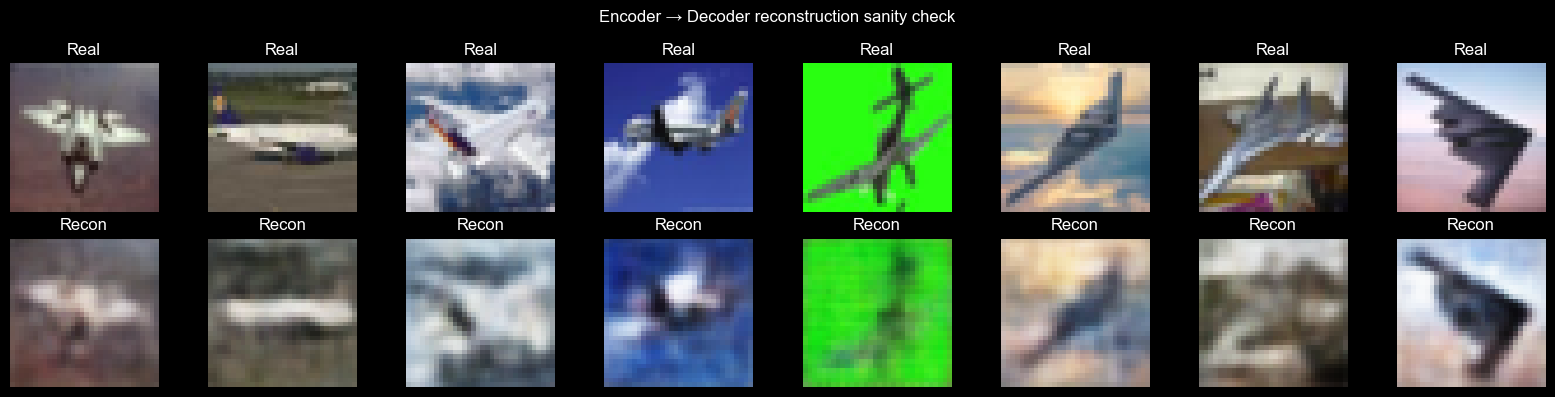

In [9]:
# Sanity check: reconstruct a few real images through encoder -> decoder
with torch.no_grad():
    sample_emb = real_emb[:8].to(DEVICE)
    recon_imgs = img_decoder(sample_emb).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(real_x[i].permute(1, 2, 0).numpy())
    axes[0, i].set_title('Real')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_imgs[i].permute(1, 2, 0).clamp(0, 1).numpy())
    axes[1, i].set_title('Recon')
    axes[1, i].axis('off')
plt.suptitle('Encoder → Decoder reconstruction sanity check')
plt.tight_layout()
plt.show()

## 7. Helpers

In [10]:
def compute_noise_multiplier(target_epsilon, delta, sample_count, batch_size, epochs):
    """Compute Opacus noise multiplier for a target epsilon."""
    if target_epsilon is None or target_epsilon == 0:
        return 0.0
    sample_rate = min(batch_size, sample_count) / max(1, sample_count)
    if sample_rate >= 1.0:
        sample_rate = 0.99
    return float(get_noise_multiplier(
        target_epsilon=float(target_epsilon),
        target_delta=float(delta),
        sample_rate=sample_rate,
        epochs=int(epochs),
    ))


def vae_loss_per_sample(recon, target, mu, logvar, kl_weight=1.0):
    """Compute per-sample VAE loss (required for Opacus)."""
    # Per-sample MSE reconstruction loss
    recon_loss = F.mse_loss(recon, target, reduction='none').sum(dim=-1)
    # Per-sample KL divergence
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=-1)
    return (recon_loss + kl_weight * kl).mean()


def train_embedding_vae_dp(
    embeddings: torch.Tensor,
    labels: torch.Tensor,
    target_epsilon,
):
    """
    Train a per-label DP-VAE on embeddings.
    Returns (synthetic_embeddings, synthetic_labels, epsilon_per_label).
    """
    syn_embs, syn_labels = [], []
    eps_per_label = {}

    for lbl in torch.unique(labels):
        lbl_val = int(lbl.item())
        mask = labels == lbl
        lbl_emb = embeddings[mask]
        n_samples = len(lbl_emb)

        noise = compute_noise_multiplier(target_epsilon, DELTA, n_samples, VAE_BATCH_SIZE, VAE_EPOCHS)

        model = EmbeddingVAE(EMBEDDING_DIM, VAE_HIDDEN_DIM, VAE_LATENT_DIM).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=VAE_LR)
        dl = DataLoader(TensorDataset(lbl_emb), batch_size=VAE_BATCH_SIZE, shuffle=True)

        if noise > 0:
            privacy_engine = PrivacyEngine()
            model, optimizer, dl = privacy_engine.make_private(
                module=model,
                optimizer=optimizer,
                data_loader=dl,
                noise_multiplier=noise,
                max_grad_norm=MAX_GRAD_NORM,
            )
        else:
            privacy_engine = None

        model.train()
        for epoch in range(VAE_EPOCHS):
            kl_weight = min(1.0, epoch / max(1, KL_WARMUP))
            for (x_batch,) in dl:
                x_batch = x_batch.to(DEVICE)
                optimizer.zero_grad()
                recon, mu, logvar = model(x_batch)
                loss = vae_loss_per_sample(recon, x_batch, mu, logvar, kl_weight)
                loss.backward()
                optimizer.step()

        if privacy_engine and noise > 0:
            epsilon = privacy_engine.get_epsilon(DELTA)
        else:
            epsilon = float('inf')
        eps_per_label[lbl_val] = epsilon

        # Generate synthetic embeddings
        model.eval()
        decode_fn = model.decode if hasattr(model, 'decode') else model._module.decode
        with torch.no_grad():
            z = torch.randn(SYN_COUNT_PER_CLASS, VAE_LATENT_DIM, device=DEVICE)
            syn_e = decode_fn(z).cpu()
        syn_embs.append(syn_e)
        syn_labels.append(torch.full((SYN_COUNT_PER_CLASS,), lbl_val, dtype=torch.long))

        eps_str = f'{epsilon:.2f}' if epsilon < float('inf') else 'inf'
        print(f'  Label {lbl_val}: n={n_samples}, noise={noise:.4f}, eps={eps_str}')

        release_device_memory(model, optimizer)

    return torch.cat(syn_embs), torch.cat(syn_labels), eps_per_label


print('Helpers defined.')

Helpers defined.


## 8. Downstream Classifier Helpers

In [11]:
def train_classifier(train_ds, epochs, lr):
    model = CIFAR_CNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_ds, batch_size=CLS_BATCH_SIZE, shuffle=True)

    model.train()
    total_loss, total_batches = 0.0, 0
    for _ in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            total_batches += 1
    return model, total_loss / max(total_batches, 1)


def evaluate_classifier(model, eval_ds):
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(eval_ds, batch_size=CLS_BATCH_SIZE, shuffle=False)

    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_probs, all_preds = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            probs = F.softmax(logits, dim=1)
            loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item() * labels.size(0)
            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()
    all_preds = torch.cat(all_preds).numpy()

    try:
        auc = float(roc_auc_score(all_labels, all_probs, multi_class='ovr'))
    except ValueError:
        auc = 0.5
    try:
        ap = float(average_precision_score(all_labels, all_probs, average='macro'))
    except ValueError:
        ap = 0.5

    return {
        'loss': total_loss / max(total, 1),
        'acc': correct / max(total, 1),
        'auc': auc,
        'precision': float(precision_score(all_labels, all_preds, average='macro', zero_division=0)),
        'recall': float(recall_score(all_labels, all_preds, average='macro', zero_division=0)),
        'f1': float(f1_score(all_labels, all_preds, average='macro', zero_division=0)),
        'ap': ap,
    }


def benchmark_classifier(train_ds, eval_ds, epochs, lr):
    model, train_loss = train_classifier(train_ds, epochs=epochs, lr=lr)
    metrics = evaluate_classifier(model, eval_ds)
    metrics['train_loss'] = float(train_loss)
    release_device_memory(model)
    return metrics


print('Classifier helpers defined.')

Classifier helpers defined.


## 9. Real-Data Baselines

In [12]:
real_subset_ds = TensorDataset(real_x, real_y)
real_test_ds = TensorDataset(test_x, test_y)

seed_everything(SEED)
real_baseline = benchmark_classifier(real_subset_ds, real_test_ds, epochs=CLS_EPOCHS, lr=CLS_LR)
print(f"Real-data baseline: acc={real_baseline['acc']:.4f}, f1={real_baseline['f1']:.4f}, auc={real_baseline['auc']:.4f}")

Real-data baseline: acc=0.5529, f1=0.5441, auc=0.9101


## 10. Privacy Sweep: Train DP-VAE on Embeddings and Evaluate

For each epsilon budget:
1. Train per-label DP-VAE on embeddings
2. Generate synthetic embeddings
3. Decode synthetic embeddings → synthetic images (using the non-DP image decoder)
4. Train CIFAR-CNN on synthetic images only
5. Test on real CIFAR-10 test set

In [13]:
records = []
synthetic_cache = {}

for eps in EPSILON_GRID:
    eps_label = 'no-DP' if eps is None else f'eps={eps:g}'
    print(f'\n=== {eps_label} ===')

    seed_everything(SEED)

    # 1. Train DP-VAE on embeddings
    syn_emb, syn_y, eps_by_label = train_embedding_vae_dp(real_emb, real_y, eps)

    # 2. Decode synthetic embeddings to images
    with torch.no_grad():
        syn_imgs = []
        for i in range(0, len(syn_emb), 256):
            batch = syn_emb[i:i+256].to(DEVICE)
            imgs = img_decoder(batch).cpu().clamp(0, 1)
            syn_imgs.append(imgs)
        syn_x = torch.cat(syn_imgs, dim=0)

    print(f'  Generated {len(syn_x)} synthetic images')
    synthetic_cache[eps_label] = (syn_x.clone(), syn_y.clone())

    # 3. Downstream evaluation: train on synthetic only, test on real
    syn_train_ds = TensorDataset(syn_x, syn_y)
    seed_everything(SEED)
    downstream = benchmark_classifier(syn_train_ds, real_test_ds, epochs=CLS_EPOCHS, lr=CLS_LR)

    mean_eps = float(np.mean(list(eps_by_label.values())))
    rec = {
        'eps_label': eps_label,
        'target_epsilon': np.inf if eps is None else float(eps),
        'mean_epsilon': mean_eps,
        'synthetic_n': int(len(syn_x)),
        'test_acc': downstream['acc'],
        'test_f1': downstream['f1'],
        'test_auc': downstream['auc'],
        'test_precision': downstream['precision'],
        'test_recall': downstream['recall'],
        'test_ap': downstream['ap'],
        'test_loss': downstream['loss'],
        'train_loss': downstream['train_loss'],
    }
    records.append(rec)

    print(f"  Downstream: acc={rec['test_acc']:.4f}, f1={rec['test_f1']:.4f}, auc={rec['test_auc']:.4f}")
    release_device_memory()

results_df = pd.DataFrame(records)
results_df


=== no-DP ===
  Label 0: n=500, noise=0.0000, eps=inf
  Label 1: n=500, noise=0.0000, eps=inf
  Label 2: n=500, noise=0.0000, eps=inf
  Label 3: n=500, noise=0.0000, eps=inf
  Label 4: n=500, noise=0.0000, eps=inf
  Label 5: n=500, noise=0.0000, eps=inf
  Label 6: n=500, noise=0.0000, eps=inf
  Label 7: n=500, noise=0.0000, eps=inf
  Label 8: n=500, noise=0.0000, eps=inf
  Label 9: n=500, noise=0.0000, eps=inf
  Generated 5000 synthetic images
  Downstream: acc=0.2098, f1=0.1953, auc=0.6415

=== eps=8 ===


<repo>/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


  Label 0: n=500, noise=2.6416, eps=7.34
  Label 1: n=500, noise=2.6416, eps=7.34
  Label 2: n=500, noise=2.6416, eps=7.34
  Label 3: n=500, noise=2.6416, eps=7.34
  Label 4: n=500, noise=2.6416, eps=7.34
  Label 5: n=500, noise=2.6416, eps=7.34
  Label 6: n=500, noise=2.6416, eps=7.34
  Label 7: n=500, noise=2.6416, eps=7.34
  Label 8: n=500, noise=2.6416, eps=7.34
  Label 9: n=500, noise=2.6416, eps=7.34
  Generated 5000 synthetic images
  Downstream: acc=0.2209, f1=0.2063, auc=0.6660

=== eps=1 ===


<repo>/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


  Label 0: n=500, noise=15.9375, eps=0.92
  Label 1: n=500, noise=15.9375, eps=0.92
  Label 2: n=500, noise=15.9375, eps=0.92
  Label 3: n=500, noise=15.9375, eps=0.92
  Label 4: n=500, noise=15.9375, eps=0.92
  Label 5: n=500, noise=15.9375, eps=0.92
  Label 6: n=500, noise=15.9375, eps=0.92
  Label 7: n=500, noise=15.9375, eps=0.92
  Label 8: n=500, noise=15.9375, eps=0.92
  Label 9: n=500, noise=15.9375, eps=0.92
  Generated 5000 synthetic images
  Downstream: acc=0.1333, f1=0.1106, auc=0.5496


,eps_label,target_epsilon,mean_epsilon,synthetic_n,test_acc,test_f1,test_auc,test_precision,test_recall,test_ap,test_loss,train_loss
0,no-DP,inf,inf,5000,0.2098,0.195250,0.641507,0.231394,0.2098,0.181155,10.034857,0.172343
1,eps=8,8.0,7.335059,5000,0.2209,0.206318,0.665982,0.212645,0.2209,0.184310,9.756348,0.137940
2,eps=1,1.0,0.915417,5000,0.1333,0.110619,0.549612,0.128817,0.1333,0.125222,8.866439,0.195043


## 11. Results Comparison

In [14]:
# Side-by-side comparison table
comparison = results_df[['eps_label', 'mean_epsilon', 'test_acc', 'test_f1', 'test_auc', 'test_ap']].copy()
comparison.loc[len(comparison)] = {
    'eps_label': 'REAL DATA',
    'mean_epsilon': '-',
    'test_acc': real_baseline['acc'],
    'test_f1': real_baseline['f1'],
    'test_auc': real_baseline['auc'],
    'test_ap': real_baseline['ap'],
}
print('\nDownstream utility: synthetic-only training vs real-data baseline')
print('=' * 80)
comparison


Downstream utility: synthetic-only training vs real-data baseline


,eps_label,mean_epsilon,test_acc,test_f1,test_auc,test_ap
0,no-DP,inf,0.2098,0.195250,0.641507,0.181155
1,eps=8,7.335059,0.2209,0.206318,0.665982,0.184310
2,eps=1,0.915417,0.1333,0.110619,0.549612,0.125222
3,REAL DATA,-,0.5529,0.544075,0.910118,0.615731


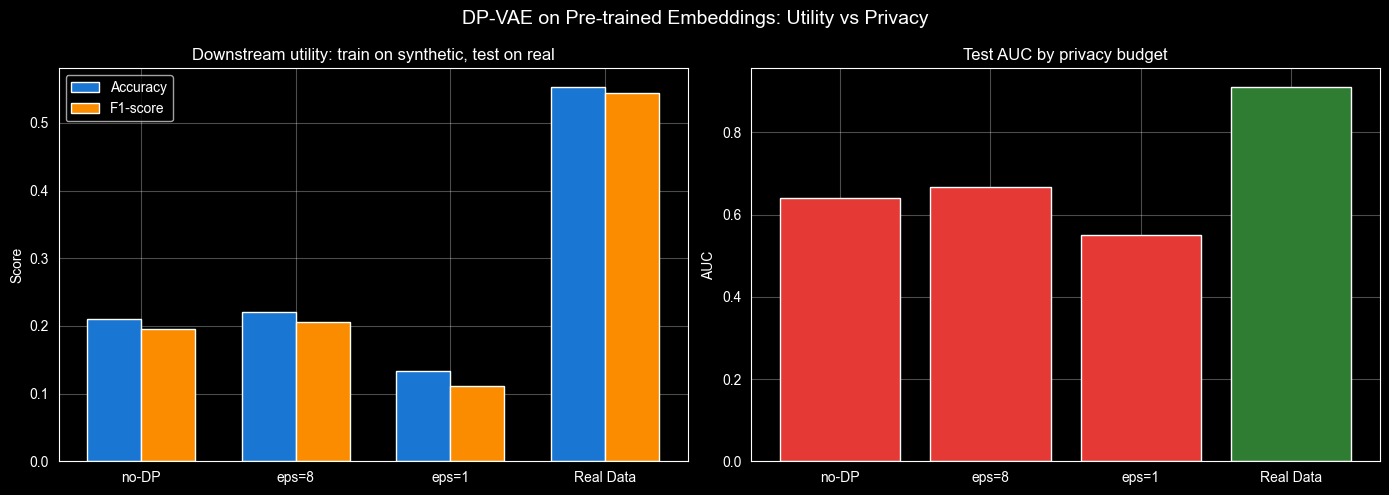

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: accuracy comparison
labels = list(results_df['eps_label']) + ['Real Data']
accs = list(results_df['test_acc']) + [real_baseline['acc']]
f1s = list(results_df['test_f1']) + [real_baseline['f1']]

x_pos = np.arange(len(labels))
width = 0.35
axes[0].bar(x_pos - width/2, accs, width, label='Accuracy', color='#1976D2')
axes[0].bar(x_pos + width/2, f1s, width, label='F1-score', color='#FB8C00')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Score')
axes[0].set_title('Downstream utility: train on synthetic, test on real')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC comparison
aucs = list(results_df['test_auc']) + [real_baseline['auc']]
colors = ['#E53935' if l != 'Real Data' else '#2E7D32' for l in labels]
axes[1].bar(x_pos, aucs, color=colors)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('AUC')
axes[1].set_title('Test AUC by privacy budget')
axes[1].grid(True, alpha=0.3)

plt.suptitle('DP-VAE on Pre-trained Embeddings: Utility vs Privacy', fontsize=14)
plt.tight_layout()
plt.show()

## 12. Synthetic Sample Grids

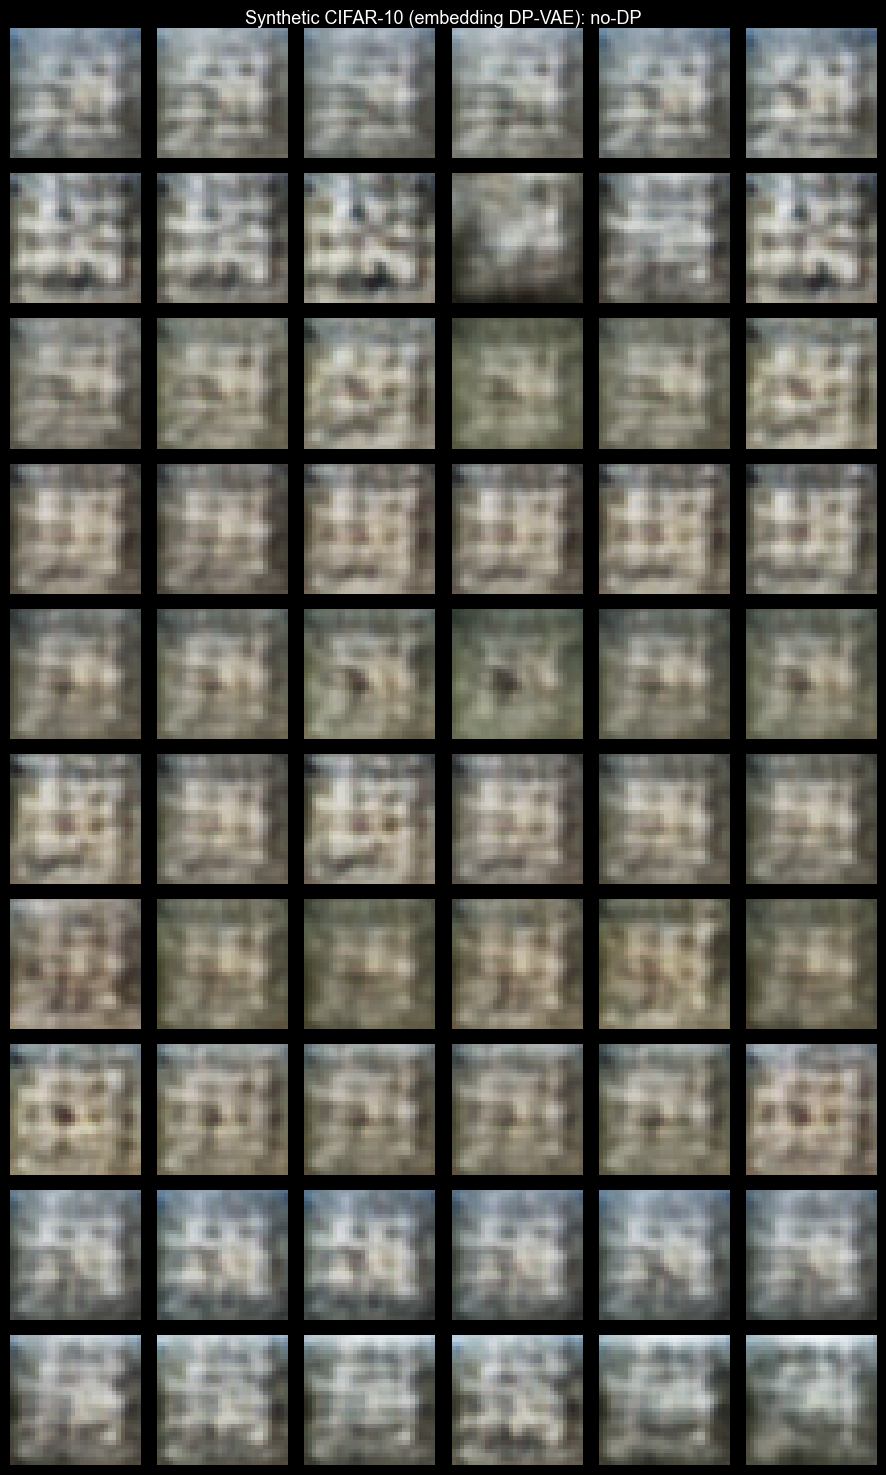

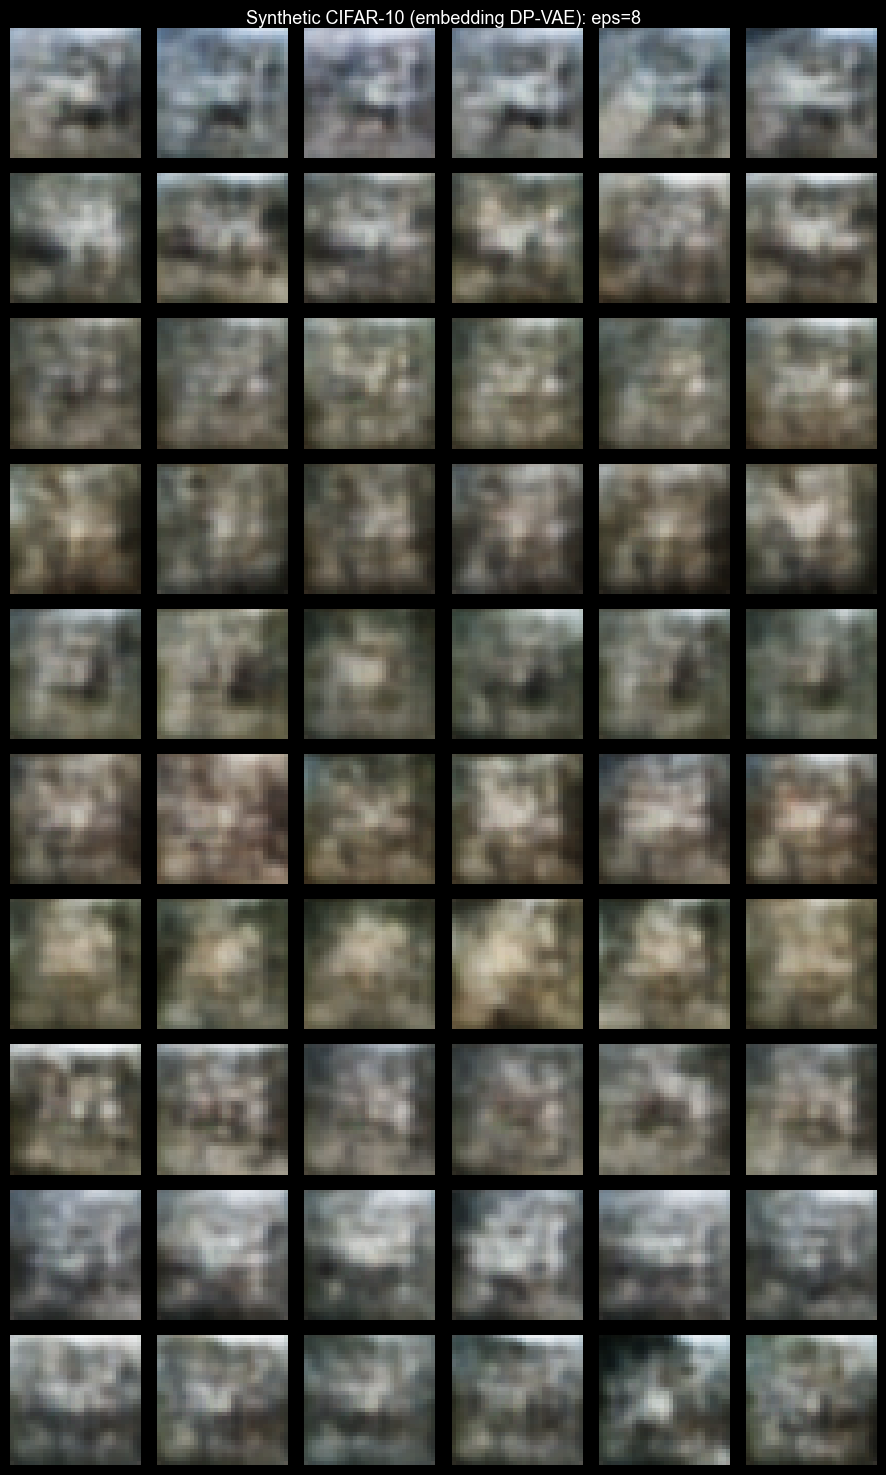

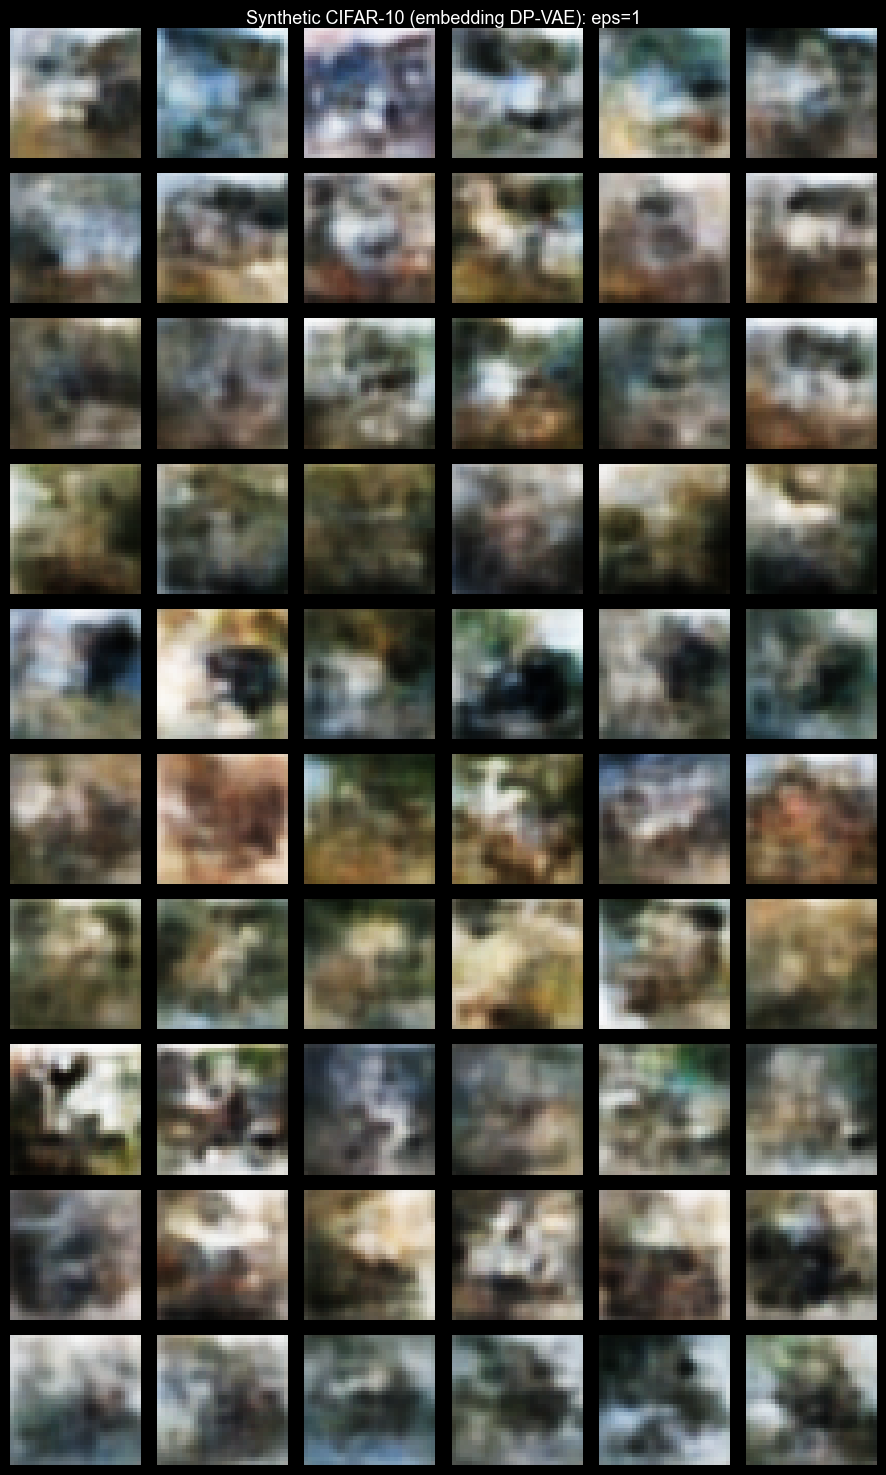

In [16]:
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

for eps_label, (syn_x, syn_y) in synthetic_cache.items():
    fig, axes = plt.subplots(10, 6, figsize=(9, 15))
    fig.suptitle(f'Synthetic CIFAR-10 (embedding DP-VAE): {eps_label}', fontsize=13)
    for lbl in range(10):
        lbl_imgs = syn_x[syn_y == lbl]
        for col in range(6):
            ax = axes[lbl, col]
            if col < len(lbl_imgs):
                ax.imshow(lbl_imgs[col].permute(1, 2, 0).clamp(0, 1).numpy())
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(cifar_classes[lbl], rotation=0, labelpad=50, fontsize=9)
    plt.tight_layout()
    plt.show()

## 13. Save Results

In [ ]:
out_csv = REPO_ROOT / 'results' / 'cifar_dp_vae_pretrained_embeddings.csv'
out_csv.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(out_csv, index=False)
print('Saved:', out_csv)

## 14. Key Takeaways

**Why this approach works:**
- The pre-trained ResNet-18 encoder maps raw pixels to a dense, semantically meaningful 512-dim space
- The DP-VAE is tiny (~330K params vs millions for a pixel-space ConvVAE), so DP noise causes far less damage
- Training completes in minutes even on CPU
- No BatchNorm anywhere — the MLP VAE uses plain linear layers, the image decoder uses GroupNorm

**Opacus implementation notes:**
- `ModuleValidator.fix()` is not needed here because the MLP VAE has no BatchNorm layers
- Large logical batch sizes (256+) help the gradient signal survive DP noise injection
- `BatchMemoryManager` can be used if GPU memory is tight (not needed for this tiny model)
- Per-label training gives better results than all-class training under DP constraints

## 15. Augmented Training: Real + Synthetic (5-seed average)

Simulate a federated scenario where a client has **limited real data** per class.
We augment with synthetic data and measure whether downstream utility improves.

For each real-data budget (10, 50, 100 samples/class):
- **Real baseline** — train on only N real samples per class
- **Augmented** — combine N real samples + all synthetic data (500/class) from each DP condition

Each experiment is repeated **5 times** with different seeds for the downstream classifier,
and we report **mean ± std** accuracy.

In [21]:
AUG_REAL_PER_CLASS = [10, 50, 100]
CONDITIONS = ['no-DP', 'eps=8', 'eps=1']
N_RUNS = 5
RUN_SEEDS = [SEED + i for i in range(N_RUNS)]  # [42, 43, 44, 45, 46]

# --- Synthetic-only: re-evaluate with multiple seeds ---
syn_only_accs = {}  # condition -> list of accs
for cond in CONDITIONS:
    syn_x_c, syn_y_c = synthetic_cache[cond]
    syn_ds = TensorDataset(syn_x_c, syn_y_c)
    accs = []
    for s in RUN_SEEDS:
        seed_everything(s)
        met = benchmark_classifier(syn_ds, real_test_ds, epochs=CLS_EPOCHS, lr=CLS_LR)
        accs.append(met['acc'])
    syn_only_accs[cond] = accs
    print(f'Synthetic-only {cond}: {np.mean(accs)*100:.2f} +/- {np.std(accs)*100:.2f}')

# --- Real baselines at each data budget ---
real_baseline_accs = {}  # n_real -> list of accs
for n_real in AUG_REAL_PER_CLASS:
    sub_x, sub_y = sample_n_per_class(real_x, real_y, n_per_class=n_real, seed=SEED)
    sub_ds = TensorDataset(sub_x, sub_y)
    accs = []
    for s in RUN_SEEDS:
        seed_everything(s)
        met = benchmark_classifier(sub_ds, real_test_ds, epochs=CLS_EPOCHS, lr=CLS_LR)
        accs.append(met['acc'])
    real_baseline_accs[n_real] = accs
    print(f'Real baseline ({n_real}/class): {np.mean(accs)*100:.2f} +/- {np.std(accs)*100:.2f}')

# --- Augmented: N real + synthetic for each condition x budget ---
aug_accs = {}  # (condition, n_real) -> list of accs
for n_real in AUG_REAL_PER_CLASS:
    sub_x, sub_y = sample_n_per_class(real_x, real_y, n_per_class=n_real, seed=SEED)
    for cond in CONDITIONS:
        syn_x_c, syn_y_c = synthetic_cache[cond]
        aug_x = torch.cat([sub_x, syn_x_c], dim=0)
        aug_y = torch.cat([sub_y, syn_y_c], dim=0)
        aug_ds = TensorDataset(aug_x, aug_y)
        accs = []
        for s in RUN_SEEDS:
            seed_everything(s)
            met = benchmark_classifier(aug_ds, real_test_ds, epochs=CLS_EPOCHS, lr=CLS_LR)
            accs.append(met['acc'])
        aug_accs[(cond, n_real)] = accs
        print(f'  {cond:>6s} + {n_real:>3d} real/class: {np.mean(accs)*100:.2f} +/- {np.std(accs)*100:.2f}')
    release_device_memory()

print(f'\nAll augmentation experiments complete ({N_RUNS} seeds each).')

Synthetic-only no-DP: 19.93 +/- 0.68
Synthetic-only eps=8: 20.68 +/- 1.20
Synthetic-only eps=1: 13.45 +/- 0.82
Real baseline (10/class): 22.19 +/- 1.35
Real baseline (50/class): 34.16 +/- 1.73
Real baseline (100/class): 39.51 +/- 1.38
   no-DP +  10 real/class: 25.05 +/- 1.56
   eps=8 +  10 real/class: 25.33 +/- 0.82
   eps=1 +  10 real/class: 17.88 +/- 1.34
   no-DP +  50 real/class: 35.73 +/- 1.03
   eps=8 +  50 real/class: 35.47 +/- 1.38
   eps=1 +  50 real/class: 30.84 +/- 0.49
   no-DP + 100 real/class: 40.98 +/- 0.87
   eps=8 + 100 real/class: 40.78 +/- 1.39
   eps=1 + 100 real/class: 38.14 +/- 1.52

All augmentation experiments complete (5 seeds each).


### Results Table (5-seed average)

Downstream test accuracy (%) on real CIFAR-10 when training on synthetic data.
Values are **mean ± std** over 5 runs. Percentage-point (pp) changes compare
augmented mean to synthetic-only mean for each condition.

In [22]:
# Build the table matching Table 5.1 format with mean +/- std
def fmt_acc(accs):
    """Format accuracy list as 'mean +/- std'."""
    return f'{np.mean(accs)*100:.2f} \u00b1 {np.std(accs)*100:.2f}'


def fmt_acc_with_pp(accs, baseline_accs):
    """Format accuracy with pp change vs baseline."""
    mean_a = np.mean(accs) * 100
    std_a = np.std(accs) * 100
    mean_b = np.mean(baseline_accs) * 100
    diff = mean_a - mean_b
    arrow = '\u2191' if diff > 0 else '\u2193'
    return f'{mean_a:.2f} \u00b1 {std_a:.2f}   ({arrow}{abs(diff):.1f} pp)'


rows = []

# Real baseline row
real_row = {'Condition': 'Real baseline', 'Synthetic-only': ''}
for n_real in AUG_REAL_PER_CLASS:
    real_row[f'Augmented ({n_real}/class)'] = fmt_acc(real_baseline_accs[n_real])
rows.append(real_row)

# DP condition rows
for cond in CONDITIONS:
    row = {
        'Condition': cond,
        'Synthetic-only': fmt_acc(syn_only_accs[cond]),
    }
    for n_real in AUG_REAL_PER_CLASS:
        row[f'Augmented ({n_real}/class)'] = fmt_acc_with_pp(
            aug_accs[(cond, n_real)], syn_only_accs[cond]
        )
    rows.append(row)

aug_table_df = pd.DataFrame(rows)
print(f'\nDownstream test accuracy (%) — mean \u00b1 std over {N_RUNS} seeds')
print('=' * 120)
aug_table_df


Downstream test accuracy (%) — mean ± std over 5 seeds


,Condition,Synthetic-only,Augmented (10/class),Augmented (50/class),Augmented (100/class)
0,Real baseline,,22.19 ± 1.35,34.16 ± 1.73,39.51 ± 1.38
1,no-DP,19.93 ± 0.68,25.05 ± 1.56 (↑5.1 pp),35.73 ± 1.03 (↑15.8 pp),40.98 ± 0.87 (↑21.1 pp)
2,eps=8,20.68 ± 1.20,25.33 ± 0.82 (↑4.7 pp),35.47 ± 1.38 (↑14.8 pp),40.78 ± 1.39 (↑20.1 pp)
3,eps=1,13.45 ± 0.82,17.88 ± 1.34 (↑4.4 pp),30.84 ± 0.49 (↑17.4 pp),38.14 ± 1.52 (↑24.7 pp)


In [23]:
# Styled HTML table with colored pp annotations and +/- std
def style_aug_table_multi_seed():
    """Build an HTML table with colored pp annotations (multi-seed)."""
    html = '<table style="border-collapse: collapse; font-family: sans-serif; font-size: 13px;">\n'
    # Header
    cols = ['Condition', 'Synthetic-only'] + [f'Augmented ({n}/class)' for n in AUG_REAL_PER_CLASS]
    html += '<tr style="border-bottom: 2px solid #333;">'
    for c in cols:
        html += f'<th style="padding: 6px 14px; text-align: center;">{c}</th>'
    html += '</tr>\n'
    # Real baseline row
    html += '<tr style="border-bottom: 1px solid #ccc;">'
    html += '<td style="padding: 6px 14px; font-weight: bold;">Real baseline</td>'
    html += '<td style="padding: 6px 14px; text-align: center;"></td>'
    for n_real in AUG_REAL_PER_CLASS:
        m = np.mean(real_baseline_accs[n_real]) * 100
        s = np.std(real_baseline_accs[n_real]) * 100
        html += f'<td style="padding: 6px 14px; text-align: center;">{m:.2f} \u00b1 {s:.2f}</td>'
    html += '</tr>\n'
    # DP condition rows
    for cond in CONDITIONS:
        syn_mean = np.mean(syn_only_accs[cond]) * 100
        syn_std = np.std(syn_only_accs[cond]) * 100
        label = f'no-DP (\u03b5 = \u221e)' if cond == 'no-DP' else f'\u03b5 = {cond.split("=")[1]}'
        html += '<tr style="border-bottom: 1px solid #eee;">'
        html += f'<td style="padding: 6px 14px;">{label}</td>'
        html += f'<td style="padding: 6px 14px; text-align: center;">{syn_mean:.2f} \u00b1 {syn_std:.2f}</td>'
        for n_real in AUG_REAL_PER_CLASS:
            a_mean = np.mean(aug_accs[(cond, n_real)]) * 100
            a_std = np.std(aug_accs[(cond, n_real)]) * 100
            diff_pp = a_mean - syn_mean
            arrow = '\u2191' if diff_pp > 0 else '\u2193'
            color = '#1976D2' if diff_pp > 0 else '#E53935'
            html += '<td style="padding: 6px 14px; text-align: center;">'
            html += f'{a_mean:.2f} \u00b1 {a_std:.2f} '
            html += f'<span style="color: {color}; font-size: 11px;">({arrow}{abs(diff_pp):.1f} pp)</span>'
            html += '</td>'
        html += '</tr>\n'
    html += '</table>'
    return html

from IPython.display import HTML, display
display(HTML(style_aug_table_multi_seed()))

Condition,Synthetic-only,Augmented (10/class),Augmented (50/class),Augmented (100/class)
Real baseline,,22.19 ± 1.35,34.16 ± 1.73,39.51 ± 1.38
no-DP (ε = ∞),19.93 ± 0.68,25.05 ± 1.56 (↑5.1 pp),35.73 ± 1.03 (↑15.8 pp),40.98 ± 0.87 (↑21.1 pp)
ε = 8,20.68 ± 1.20,25.33 ± 0.82 (↑4.7 pp),35.47 ± 1.38 (↑14.8 pp),40.78 ± 1.39 (↑20.1 pp)
ε = 1,13.45 ± 0.82,17.88 ± 1.34 (↑4.4 pp),30.84 ± 0.49 (↑17.4 pp),38.14 ± 1.52 (↑24.7 pp)


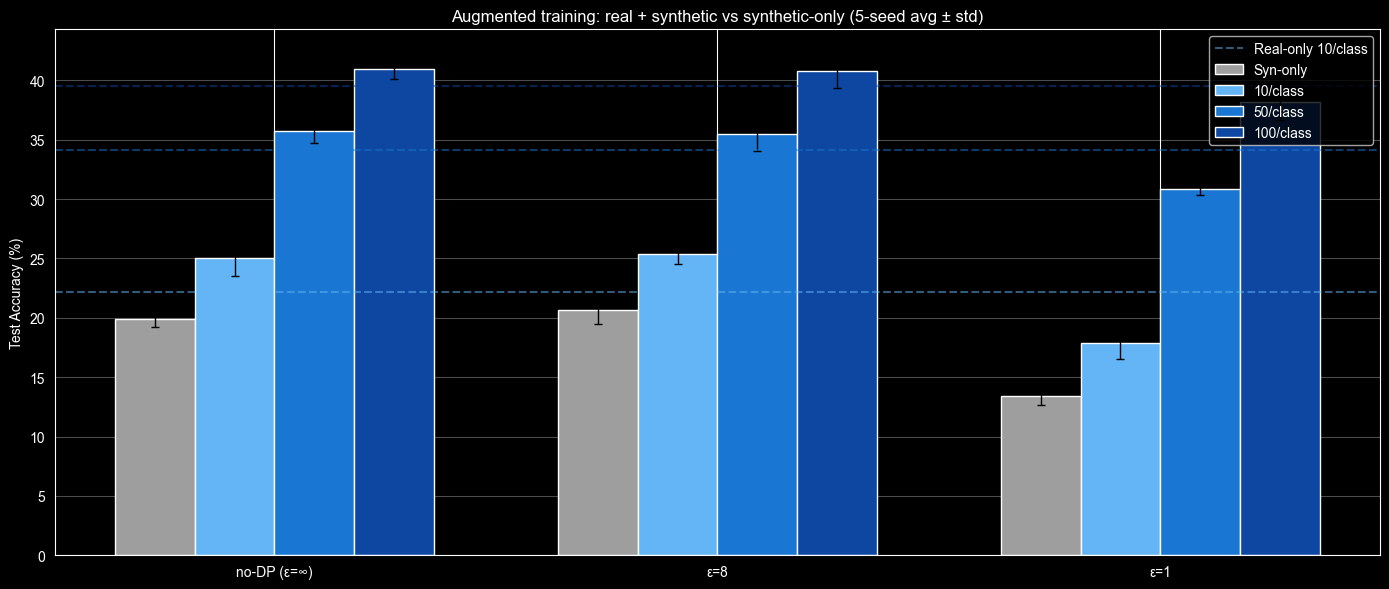

In [24]:
# Grouped bar chart with error bars
fig, ax = plt.subplots(figsize=(14, 6))

all_settings = ['Syn-only'] + [f'{n}/class' for n in AUG_REAL_PER_CLASS]
n_cond = len(CONDITIONS)
n_settings = len(all_settings)
bar_width = 0.18
x = np.arange(n_cond)

colors = ['#9E9E9E', '#64B5F6', '#1976D2', '#0D47A1']

for j, setting in enumerate(all_settings):
    means, stds = [], []
    for cond in CONDITIONS:
        if setting == 'Syn-only':
            vals = syn_only_accs[cond]
        else:
            n_real = AUG_REAL_PER_CLASS[j - 1]
            vals = aug_accs[(cond, n_real)]
        means.append(np.mean(vals) * 100)
        stds.append(np.std(vals) * 100)
    ax.bar(x + j * bar_width, means, bar_width, yerr=stds,
           label=setting, color=colors[j], capsize=3, error_kw={'linewidth': 1})

# Real baseline lines for each N
for i, n_real in enumerate(AUG_REAL_PER_CLASS):
    m = np.mean(real_baseline_accs[n_real]) * 100
    ax.axhline(m, color=colors[i+1], linestyle='--', alpha=0.5,
               label=f'Real-only {n_real}/class' if i == 0 else None)

ax.set_xticks(x + bar_width * (n_settings - 1) / 2)
ax.set_xticklabels([f'no-DP (\u03b5=\u221e)' if c == 'no-DP' else f'\u03b5={c.split("=")[1]}' for c in CONDITIONS])
ax.set_ylabel('Test Accuracy (%)')
ax.set_title(f'Augmented training: real + synthetic vs synthetic-only ({N_RUNS}-seed avg \u00b1 std)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [25]:
# Save augmentation results with per-seed detail
aug_rows = []
for cond in CONDITIONS:
    row = {
        'condition': cond,
        'synthetic_only_mean': np.mean(syn_only_accs[cond]),
        'synthetic_only_std': np.std(syn_only_accs[cond]),
    }
    for n_real in AUG_REAL_PER_CLASS:
        row[f'aug_{n_real}_mean'] = np.mean(aug_accs[(cond, n_real)])
        row[f'aug_{n_real}_std'] = np.std(aug_accs[(cond, n_real)])
        row[f'aug_{n_real}_pp_change'] = (
            np.mean(aug_accs[(cond, n_real)]) - np.mean(syn_only_accs[cond])
        ) * 100
    aug_rows.append(row)

# Real baselines
real_row = {'condition': 'real_baseline', 'synthetic_only_mean': None, 'synthetic_only_std': None}
for n_real in AUG_REAL_PER_CLASS:
    real_row[f'aug_{n_real}_mean'] = np.mean(real_baseline_accs[n_real])
    real_row[f'aug_{n_real}_std'] = np.std(real_baseline_accs[n_real])
    real_row[f'aug_{n_real}_pp_change'] = None
aug_rows.append(real_row)

aug_df = pd.DataFrame(aug_rows)
aug_csv = REPO_ROOT / 'results' / 'cifar_dp_vae_pretrained_augmentation.csv'
aug_df.to_csv(aug_csv, index=False)
print('Saved:', aug_csv)
aug_df

Saved: <repo>/results/cifar_dp_vae_pretrained_augmentation.csv


,condition,synthetic_only_mean,synthetic_only_std,aug_10_mean,aug_10_std,aug_10_pp_change,aug_50_mean,aug_50_std,aug_50_pp_change,aug_100_mean,aug_100_std,aug_100_pp_change
0,no-DP,0.19928,0.006783,0.25052,0.015630,5.124,0.35732,0.010282,15.804,0.40978,0.008746,21.050
1,eps=8,0.20678,0.012014,0.25330,0.008165,4.652,0.35466,0.013816,14.788,0.40780,0.013928,20.102
2,eps=1,0.13448,0.008227,0.17884,0.013388,4.436,0.30842,0.004915,17.394,0.38142,0.015157,24.694
3,real_baseline,NaN,NaN,0.22194,0.013550,NaN,0.34160,0.017267,NaN,0.39506,0.013788,NaN
